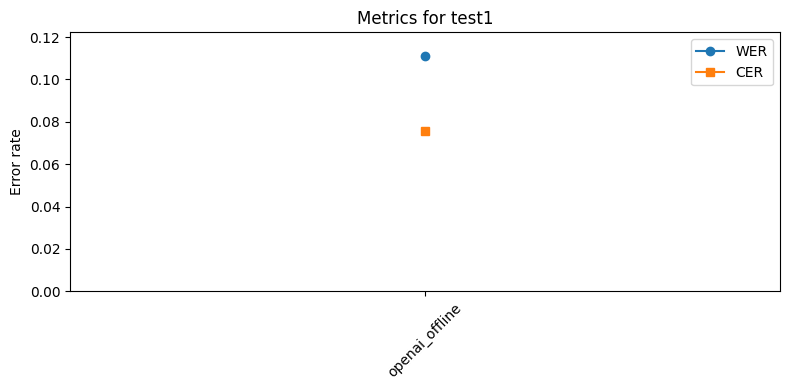

In [ ]:
# Multi-model transcription and metrics UI
import os
from pathlib import Path
from IPython.display import display, Markdown
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import importlib

# Local project imports
from transcribe import amazon_stt, google_stt, ms_azure_stt, whisperOffline
import count_metrics
from jiwer import wer, cer

# Prepare folders and file lists
base_dir = Path('.')  # notebook located in backend/ so '.' is backend/
audio_exts = ['.wav', '.mp3', '.m4a']
audio_files = [f.name for f in base_dir.iterdir() if f.suffix.lower() in audio_exts]
text_files = [f.name for f in base_dir.iterdir() if f.suffix.lower() == '.txt']

# Widgets: choose audio file from existing files or provide path
audio_dropdown = widgets.Dropdown(options=['--choose--'] + audio_files, description='Recording:')
audio_path_text = widgets.Text(placeholder='Or paste full path to audio file', description='Audio path:', layout=widgets.Layout(width='600px'))

# Reference text selection
ref_dropdown = widgets.Dropdown(options=['--choose--'] + text_files, description='Reference:')
ref_textarea = widgets.Textarea(placeholder='Or paste reference text here', description='Ref text:', layout=widgets.Layout(width='600px', height='120px'))

# Model toggles (checkboxes)
models = {
    'amazon': widgets.Checkbox(False, description='Amazon'),
    'google': widgets.Checkbox(False, description='Google'),
    'azure': widgets.Checkbox(False, description='Azure'),
    'openai_online': widgets.Checkbox(False, description='OpenAI online'),
    'openai_offline': widgets.Checkbox(False, description='OpenAI offline (local)')
}

run_button = widgets.Button(description='Run selected models', button_style='primary')
output = widgets.Output(layout={'border': '1px solid gray'})

display(widgets.VBox([audio_dropdown, audio_path_text, ref_dropdown, ref_textarea, widgets.HBox(list(models.values())), run_button, output]))

# Helper to resolve audio and reference paths
def resolve_audio_path():
    if audio_path_text.value.strip():
        return audio_path_text.value.strip()
    if audio_dropdown.value and audio_dropdown.value != '--choose--':
        return str(base_dir / audio_dropdown.value)
    return None

def resolve_reference():
    # If textarea used, write to a temp file and return path
    if ref_textarea.value.strip():
        temp_dir = base_dir / 'temp_refs'
        temp_dir.mkdir(exist_ok=True)
        p = temp_dir / f'ref_{int(os.times()[4])}.txt'
        p.write_text(ref_textarea.value, encoding='utf-8')
        return str(p)
    if ref_dropdown.value and ref_dropdown.value != '--choose--':
        return str(base_dir / ref_dropdown.value)
    return None

# Run transcription per model. Each returns transcribed text (string) or empty string on failure
def run_transcription_for_model(model_key, audio_path):
    try:
        if model_key == 'amazon':
            return amazon_stt.transcribe_file(audio_path) or ''
        if model_key == 'google':
            resp = google_stt.transcribe_file(audio_path)
            # Extract transcripts if response provided
            try:
                texts = [r.alternatives[0].transcript for r in resp.results]
                return ' '.join(texts)
            except Exception:
                return ''
        if model_key == 'azure':
            return ms_azure_stt.transcribe_file(audio_path) or ''
        if model_key == 'openai_offline':
            client = whisperOffline.LocalWhisperClient(model_size='small')
            res = client.transcribe(audio_path)
            return res.get('text','')
        if model_key == 'openai_online':
            # Try to call OpenAI API similarly to openAiWhisper.py but with given audio_path
            try:
                from openai import OpenAI
                import json, os
                # load credentials if present (optional)
                client = OpenAI()
                with open(audio_path, 'rb') as af:
                    transcription = client.audio.transcriptions.create(model='gpt-4o-transcribe', file=af)
                return getattr(transcription, 'text', '') or transcription.get('text', '')
            except Exception as e:
                print('OpenAI online transcription failed:', e)
                return ''
    except Exception as e:
        print(f'Error running model {model_key}:', e)
        return ''

# When run button is clicked
def on_run_clicked(b):
    with output:
        output.clear_output()
        ap = resolve_audio_path()
        ref = resolve_reference()
        if not ap:
            print('Please select or provide an audio file path')
            return
        if not ref:
            print('Please select or provide a reference text')
            return
        print('Audio:', ap)
        print('Reference:', ref)

        results = {}
        trans_dir = base_dir / 'transcriptions'
        trans_dir.mkdir(exist_ok=True)
        basename = Path(ap).stem

        for key, chk in models.items():
            if chk.value:
                print(f'Running {key}...')
                txt = run_transcription_for_model(key, ap)
                out_path = trans_dir / f'{key}_{basename}.txt'
                out_path.write_text(txt, encoding='utf-8')
                # call existing script to print metrics to stdout as requested
                try:
                    count_metrics.print_metrics(str(ref), str(out_path))
                except Exception as e:
                    print('count_metrics invocation failed:', e)
                # compute numeric metrics for plotting
                try:
                    w = wer(Path(ref).read_text(encoding='utf-8'), txt)
                    c = cer(Path(ref).read_text(encoding='utf-8'), txt)
                except Exception as e:
                    print('Failed computing metrics for', key, e)
                    w, c = None, None
                results[key] = {'wer': w, 'cer': c}

        # After loop, plot results for selected models
        if results:
            keys = list(results.keys())
            wers = [results[k]['wer'] if results[k]['wer'] is not None else np.nan for k in keys]
            cers = [results[k]['cer'] if results[k]['cer'] is not None else np.nan for k in keys]

            fig, ax = plt.subplots(figsize=(8,4))
            x = np.arange(len(keys))
            ax.plot(x, wers, marker='o', label='WER')
            ax.plot(x, cers, marker='s', label='CER')
            ax.set_xticks(x)
            ax.set_xticklabels(keys, rotation=45)
            ax.set_ylim(0, max([v for v in wers+cers if not np.isnan(v)] + [0.01]) * 1.1)
            ax.set_ylabel('Error rate')
            ax.set_title(f'Metrics for {basename}')
            ax.legend()
            plt.tight_layout()
            display(fig)
        else:
            print('No models were selected or no results produced')

run_button.on_click(on_run_clicked)